In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Success")

Success


In [3]:
import os
print(os.getcwd())
print(os.listdir("../"))
print(os.listdir("../data"))

c:\Users\Minakshi\Desktop\Netflix-Data-Analysis\notebooks
['.git', '.gitignore', '.venv', 'data', 'images', 'notebooks', 'README.md', 'requirements.txt']
['netflix_titles.csv']


In [4]:
with open("../data/netflix_titles.csv","r", encoding = 'utf-8') as f:
    print(f.readline())

show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description



In [5]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Netflix Movies and TV Shows - Data Analysis
## 1. Dataset Overview

In this project, we analyze Netflix Movies and TV shows to identify patterns and trends in its content library.

In [6]:
df.shape

(8807, 12)

In [7]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [8]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [9]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8470,s8471,Movie,The Push,"Grant Korgan, Brian Niles",Grant Korgan,United States,"June 7, 2019",2018,TV-MA,90 min,"Documentaries, Sports Movies","After a snowmobile accident paralyzed him, Gra..."
8662,s8663,Movie,Union Leader,Sanjay Patel,"Rahul Bhat, Tillotama Shome, Haresh Dagiya, Ja...","Canada, India","December 31, 2019",2017,TV-14,105 min,"Dramas, Independent Movies, International Movies",Toxic conditions and a corrupt union leader pr...
2514,s2515,TV Show,The Big Flower Fight,NaN,"Natasia Demetriou, Vic Reeves, Kristen Griffit...",United Kingdom,"May 18, 2020",2020,TV-PG,1 Season,"British TV Shows, International TV Shows, Real...","Ten pairs of florists, sculptors and garden de..."
7245,s7246,TV Show,Kurt Seyit & Sura,NaN,"Kıvanç Tatlıtuğ, Farah Zeynep Abdullah, Fahriy...",Turkey,"December 26, 2016",2014,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",A Turkish lieutenant and the daughter of Russi...
2167,s2168,Movie,Malibu Rescue: The Next Wave,Savage Steve Holland,"Ricardo Hurtado, Breanna Yde, Jackie R. Jacobs...",United States,"August 4, 2020",2020,TV-G,71 min,"Children & Family Movies, Comedies","As summer returns to Malibu, Team Flounder tak..."


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [11]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) *100

missing_percentage.sort_values(ascending = False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [19]:
df["director"] = df["director"].fillna("Not Given")
df["cast"] = df["cast"].fillna("Not Given")
df["country"] = df["country"].fillna("Not Given")

In [15]:
df[df["rating"].isnull()][["show_id", "type","title", "rating", "duration"]]

,show_id,type,title,rating,duration
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,37 min
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,1 Season
7312,s7313,TV Show,Little Lunch,NaN,1 Season
7537,s7538,Movie,My Honor Was Loyalty,NaN,115 min


In [17]:
df["rating"] = df["rating"].fillna("Not Rated")

In [16]:
df[df["duration"].isnull()][["show_id", "type","title", "rating", "duration"]]

,show_id,type,title,rating,duration
5541,s5542,Movie,Louis C.K. 2017,74 min,NaN
5794,s5795,Movie,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [18]:
df["duration"] = df["duration"].fillna("Not Given")

In [20]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Initial Observation 

The `release_year` variable ranges from 1925 to 2021, with a median release year of 2017. The mean release year is approximately 2014, which is lower than the median due to the presence of older titles.

The relatively high 25th, 50th, and 75th percentiles suggest that a large proprtion of the titles in the dataset were released in recent years.

### Understand and clean date_added


In [21]:
df["date_added"].dtype

<StringDtype(storage='python', na_value=nan)>

In [26]:
df[df["date_added"].isnull()][["show_id", "title", "date_added"]]

,show_id,title,date_added
6066,s6067,A Young Doctor's Notebook and Other Stories,NaT
6174,s6175,Anthony Bourdain: Parts Unknown,NaT
6795,s6796,Frasier,NaT
6806,s6807,Friends,NaT
6901,s6902,Gunslinger Girl,NaT
7196,s7197,Kikoriki,NaT
7254,s7255,La Familia P. Luche,NaT
7406,s7407,Maron,NaT
7847,s7848,Red vs. Blue,NaT
8182,s8183,The Adventures of Figaro Pho,NaT


In [29]:

df["date_added"] = pd.to_datetime(df["date_added"])

In [28]:
df["date_added"].dtype

dtype('<M8[us]')

In [30]:
df["date_added"].isnull().sum()

np.int64(10)

## EDA


In [32]:
df["type"].value_counts(normalize = True)*100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

### Observation
 
 The dataset contains 6,131 Movies and 2,676 TV Shows. Movies account for approximately 69.6% of the titles, while TV Shows account for approximately 30.4%. Therefore, Movies make up the larger share of the Netflix catalog represented in this dataset.

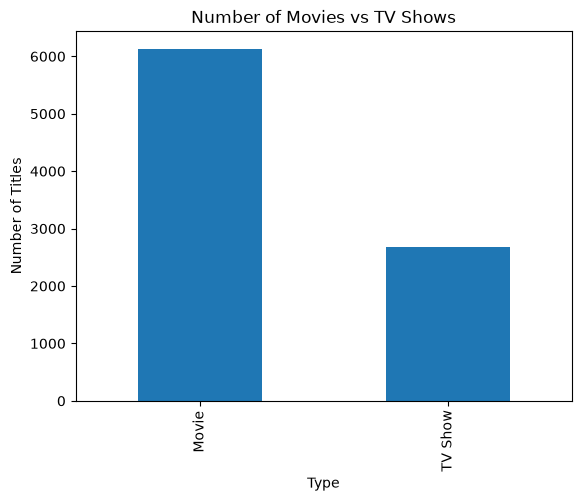

In [35]:
df["type"].value_counts().plot(kind = "bar")

plt.title("Number of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.savefig("../visualizations/movies_vs_tv_shows.png", bbox_inches = "tight")
plt.show()

In [38]:
df["date_added_year"] = df["date_added"].dt.year
df["date_added_year"].value_counts().sort_index()

date_added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

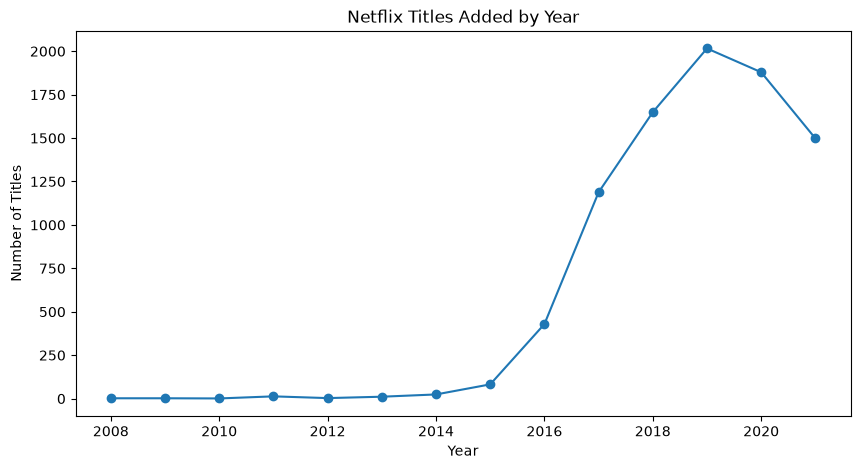

In [39]:
yearly_additions = df["date_added_year"].value_counts().sort_index()

plt.figure(figsize = (10,5))
plt.plot(yearly_additions.index, yearly_additions.values, marker = 'o')

plt.title("Netflix Titles Added by Year")
plt.xlabel('Year')
plt.ylabel("Number of Titles")

plt.savefig("../visualizations/titles_added_by-year.png", bbox_inches = "tight")

plt.show()

### Observation 
The number of titles added to Netflix increased substantially from 2015 onward, reaching peak of 2,016 titles in 2019. The number of additions then declined to 1,879 in 2020 and 1,498 in 2021. This suggests that the dataset contains a strong increase in Netflix catalog additions during the late 2010s, followed by a decline in the final years represented.


In [43]:
year_type = df.groupby(["date_added_year", "type"]).size()
year_type

date_added_year  type   
2008.0           Movie         1
                 TV Show       1
2009.0           Movie         2
2010.0           Movie         1
2011.0           Movie        13
2012.0           Movie         3
2013.0           Movie         6
                 TV Show       5
2014.0           Movie        19
                 TV Show       5
2015.0           Movie        56
                 TV Show      26
2016.0           Movie       253
                 TV Show     176
2017.0           Movie       839
                 TV Show     349
2018.0           Movie      1237
                 TV Show     412
2019.0           Movie      1424
                 TV Show     592
2020.0           Movie      1284
                 TV Show     595
2021.0           Movie       993
                 TV Show     505
dtype: int64

In [44]:
year_type = df.groupby(["date_added_year", "type"]).size().unstack()
year_type

type,Movie,TV Show
date_added_year,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,5.0
2014.0,19.0,5.0
2015.0,56.0,26.0
2016.0,253.0,176.0


In [45]:
year_type_percentage = year_type.div(year_type.sum(axis = 1), axis = 0)*100
year_type_percentage

type,Movie,TV Show
date_added_year,,
2008.0,50.000000,50.000000
2009.0,100.000000,NaN
2010.0,100.000000,NaN
2011.0,100.000000,NaN
2012.0,100.000000,NaN
2013.0,54.545455,45.454545
2014.0,79.166667,20.833333
2015.0,68.292683,31.707317
2016.0,58.974359,41.025641


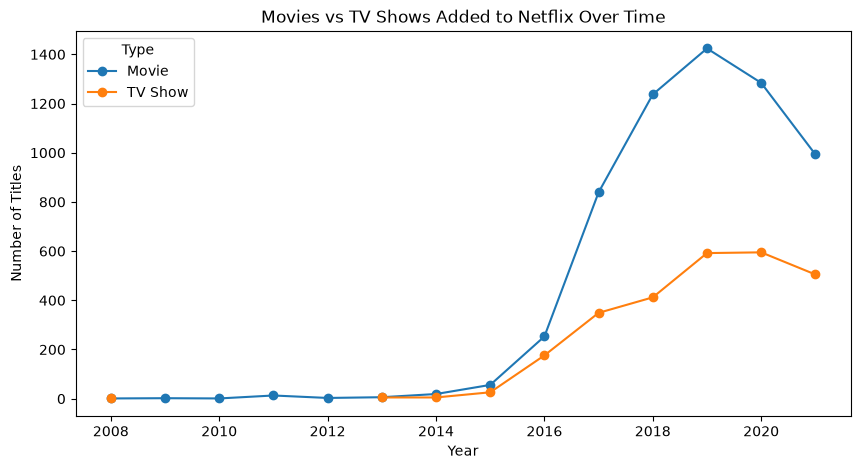

In [47]:
year_type.plot(
    kind = "line",
    marker = 'o',
    figsize=(10,5),
)

plt.title("Movies vs TV Shows Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title = "Type")

plt.savefig(
    "../visualizations/movies_vs_tv_shows_over_time.png",
    bbox_inches = "tight"
)

plt.show()

### Observation
The number of Movies added to Netflix increased substantially from 2015 and reached peak of 1,424 titles in 2019 before declining in 2020 and 2021. TV Show additions also increased over the same period, reaching a peak pf 595 titles in 2020. Although Movies remained the larger category throughout the period, the proportion of TV Shows increased from approximately 29.4% in 2019 to 33.7% in 2021.
